![](images\auc_roc_1.PNG)

- ROC curve is used to visualize the performance of a binary classifier that is, the classifier with 2 possible outcomes. 
- ROC curves takes into consideration all possible thresholds and the threshold determination is done by the business.


### [Link to the ROC setup used in lecture](http://www.navan.name/roc/)


![](images\roc1.PNG)

Assume every blue and red pixel represents a paper for which we want to predict the admission status.

![](images\roc2.PNG)

Assume this is a validation dataset and we used logistic regression as it has probabilities also.

![](images\roc3.PNG)

Lets estimate that height at probability 0.1 is 10 pixels. The aboe plot tells us that there were 10 papers for which we predicted admission probability of 0.1 and true status for all 10 papers was negative i.e, not admitted. 

> blue - Not admitted  
> Red  - Admitted

There were 50 papers for which we predicted admittance probability of 0.3 and none of them were admitted (Pic-1). There were about 20 papers for which we predicted admittance proability of 0.5 but 10 were admitted and 10 (hald) were not admitted (Pic - 2). There were 50 papers for which we predicted a probability of admittance of 70% and all of them were selected (Pic - 3).

![](images\roc4.PNG)

***
***


![](images\roc5.PNG)

Most of the classifiers have a threshold of 50%.

Accuracy rate = %ge of correct predictions

At this threshold, more than 90% of the observations are classified correctly.

***

Now if our classifier did not do well with thresold of 0.5 and the blue distribution tends more towards the right. Then our classification accuracy will be much lower than before irrespective of the thresold we choose.

+ve - Admitted

-ve - Not admitted

***

Now lets discuss ROC curve:

##### True positive rate TPR - When the actual classifcation is +ve how often does the classifer predict positive. (Recall)
$$ TPR = \frac{TPs}{all-positives}  = \frac{TP}{TP + FN} $$

##### False positive rate FPR - When the actual classifcation is -ve how often does the classifer predict negative.
$$ FPR = \frac{TNs}{all-negatives}  = \frac{FP}{FP + TN} $$


Both TPR and FPR range from 0 to 1.

# ROC curve
It is a plot of the TPR  on the y-axis and FPR on the x-axis for every possible classifcation threshold.

##### Example - 

Setting up a classification threshold of 0.8 such that this threshold will classify 50 papers as admitted and 450 as not admitted.

![](images\roc6.PNG)

The TPR will be red pixels to the right of the line divided by all red pixels, i.e.,

$$ TPR = \frac{50}{250} = 0.2 $$

The FPR will be blue pixel to the right of the line divided by all blue pixels, i.e.,

$$ FPR = \frac{0}{250} = 0 $$

Thus we will plot a point on the ROC curve. Plot on ROC curve:

$$ (x,y) = (0,0.2) $$

![](images\roc7.PNG)

If we move the threshold to 0.5:

![](images\roc8.PNG)

Hence we got two points above. But to generate the ROC curve we need to generate TPR and FPR for all possible classifcaton thresholds which range from 0 to 1. Observe how the point on ROC curve moves when we chnage the threshold (refer video - 7:23).

- ROC curve visualizes all possible threshold.
- Misclassification rate is error rate for single threshold.

### Changing the threshold such that classifcation is good

![](images\roc9.PNG)

Therefore a classifier which does a very good job of seperating the classes will have a ROC curve that hugs the upper left corner of the plot.

### A poor classifier

![](images\roc10.PNG)

A poor classifer will have its ROC curve close to the diagonal and it can be equated to random guessing.

# AUC

Now to quantify the performance of the quantifier - we will use AUC - Area under the curve.

![](images\roc11.PNG)

## This example is not represesntative of real world problems

1. The example we have used here is of a perfectly balanced class that is why the size of blue and red distribution are identical. But most of the real world problems do not have a balanced class.

Ex - if only 10% papers were admitted then the blue distribution will be 9 times larger than the red distribution, however that does not change the way ROC curve is generated.

2. Predicted probabilities output by classifers are unlikely to follow a particular shape or distribution.

## Points to remember

1. ROC curves and AUC are useful even if your __predicted probabilities__ are not properly calibrated.  
   i.e., ROC curve and AUC will be identical even if your predicted probabilities range from 0.9 to 1 instead of 0 to 1 as long as ordering of observations by predictive probabilities remain the same. All the AUC metric cares about is how well your classifier seperates the two classes.
   
   AUC is only sensitive to rank ordering. We can think of AUC as representing the probability that a classifer will rank a randomly choosen positive observation higher than a randomly choosen negative observation. So  AUC is a useful metric even when your classes are highly imbalanced.  
   
 
2. ROC curves can be extended to problems with __3 or more classes__ using a __1 vs all approach__. So if we have 3 classes then we will need to create 3 ROC curves:

```
Curve 1 -> class 1 (+ve class) vs class 2 and 3 (-ve class)
Curve 2 -> class 2 (+ve class) vs class 1 and 3 (-ve class)
Curve 3 -> class 3 (+ve class) vs class 1 and 2 (-ve class)
```

3. Choosing a classiifcation threshold is a business decision: minimize FPR or maximize TPR. (In our journal admittance example it was not obvious what to choose). 

    Eg: Credit card transaction was fraudulent or not - Business decision might be set the threshold very low which will result in a lot of FPs (false +ves)  
    ![](images\roc12.PNG)
    
    But this will be considered acceptable as that will maximize the TPRs and hence minimize the casein which real instance of fraud was not flagged for review.  
    ![](images\roc13.PNG)
    
    
    In the end we always have to choose the classifcation threshold and ROC curve will visually help us understand the imapct of that choice.

***
***

# How the classification threshold is decided in practice

> ROC/AUC tells us **how well the model ranks** cases (model selection). The threshold decides **what we do with the scores** (a business decision). These are two separate steps. AUC does not depend on the threshold, so it can never tell us which threshold to use.

## Why not just use 0.5?

- 0.5 is only optimal when **a false positive costs the same as a false negative** *and* the probabilities are calibrated. That almost never holds in business problems.
- With imbalanced classes (fraud ≈ 0.1–1%, churn ≈ 5–20%) the model rarely gives a probability above 0.5, so a 0.5 cut-off flags almost nothing. Accuracy looks high, but recall is close to zero.

## The general recipe a data scientist follows

1. **Translate each confusion-matrix cell into money (or another business unit).** Ask what a TP earns, what an FP costs and what an FN costs.
2. **Write down the operational constraints.** Examples: analyst review capacity, campaign budget, the maximum share of customers we can afford to annoy, and regulatory limits.
3. **Choose the threshold on a validation set (or out-of-fold predictions), never on the test set.** The threshold is a hyperparameter like any other.
4. **Pick the strategy that fits the problem:**

| Strategy | Rule | Use it when |
|---|---|---|
| **Cost / profit-based** | Maximise $\text{profit}(t)$ or minimise $\text{cost}(t)$ | Costs can be estimated |
| **Capacity (top-K)** | Action only the K highest scores. $t$ = score of the K-th case | Fixed team size or budget |
| **Metric constraint** | e.g. *max recall s.t. precision ≥ 30%* or *FPR ≤ 0.5%* | The business states an SLA |
| **$F_\beta$ maximisation** | $\beta>1$ favours recall, $\beta<1$ favours precision | Costs are unknown, but you know which error is worse |
| **Youden's J** ($\max\ TPR-FPR$) | The point on the ROC curve farthest from the diagonal | Statistical default only. It treats both errors as equal, which is rarely true in business |

5. **Monitor the threshold after deployment.** Base rates drift, fraudsters adapt and offer costs change. A threshold that was optimal last quarter may not be optimal today.

### The cost-based (Bayes-optimal) threshold

For one case with calibrated probability $p$ of being positive, act (predict positive) when the expected gain from acting is larger than the expected loss:

$$
p \cdot B_{TP} \;>\; (1-p)\cdot C_{FP}
\quad\Longrightarrow\quad
t^{*} = \frac{C_{FP}}{B_{TP} + C_{FP}}
$$

- $B_{TP}$: net benefit of acting on a true positive, compared with doing nothing
- $C_{FP}$: cost of acting on a negative (a false alarm)
- If you write it with costs only (cost of an FN $= C_{FN}$, and a TP costs nothing), this becomes the well-known $t^{*} = \dfrac{C_{FP}}{C_{FP}+C_{FN}}$.

**Caveat:** the formula assumes **calibrated** probabilities. If you trained with `class_weight='balanced'`, SMOTE or undersampling, the probabilities are inflated. In that case, calibrate first (`CalibratedClassifierCV`) or sweep thresholds on validation data and pick the empirical optimum, as the code below does.

> In scikit-learn ≥ 1.5, `TunedThresholdClassifierCV` automates the sweep. Pass it a custom scorer built from your cost matrix (`make_scorer`), and it tunes the threshold with cross-validation inside the pipeline.

***

## Use case 1: Credit card fraud detection

**Setup.** Target = transaction is fraudulent (usually confirmed by a chargeback). Features: amount, merchant category, distance from home, time since last transaction, velocity (number of transactions in the last hour), device/IP, deviation from the customer's usual spend. Base rate ≈ 0.1–1%.

**What each outcome costs**

| Outcome | Business meaning | Typical cost |
|---|---|---|
| **FN** (missed fraud) | Bank refunds the customer and absorbs the loss and chargeback fees | The **transaction amount** $A$ (avg. maybe \$100–\$500) + fees |
| **FP** (legit flagged) | Card declined or OTP challenge, analyst time, annoyed customer | $C$ ≈ \$2–\$10 review + small churn risk |
| **TP** (fraud stopped) | Loss avoided, review still paid | Net benefit $A - C$ |

Plugging $B_{TP} = A - C$ and $C_{FP} = C$ into the formula gives a very simple rule:

$$t^* = \frac{C}{(A - C) + C} = \frac{C}{A} \qquad\Longleftrightarrow\qquad \text{flag if } p \cdot A > C$$

That is, flag a transaction when the **expected loss** $p \cdot A$ is larger than the review cost. With an average fraud of \$200 and a \$5 review, $t^* = 5/200 = 0.025$. Any transaction with more than a **2.5%** probability of fraud is worth reviewing, which is far below 0.5. This matches the ROC section above: we accept many FPs to push TPR up, because $C_{FN} \gg C_{FP}$.

**How it is really done in industry**

1. **Amount-dependent threshold.** Since $t(A) = C/A$, a \$5,000 transaction is flagged at 0.1% risk, while a \$5 coffee is never worth a review. Banks optimise **dollars of fraud caught**, not the count of frauds caught.
2. **Tiered thresholds instead of a single cut-off.** One score drives several actions:

   | Score band | Action |
   |---|---|
   | very high (e.g. $p \ge 0.90$) | Auto-decline / block card |
   | high (e.g. $0.30 \le p < 0.90$) | Step-up authentication (OTP, app push) |
   | above cost threshold | Approve, but queue for analyst review |
   | below cost threshold | Approve silently |

3. **Capacity and customer-experience constraints.** If the fraud team can review 2,000 alerts a day, the threshold is the score of roughly the 2,000th riskiest transaction, even if the cost formula says to flag more. Banks also cap the **false-decline rate** (e.g. FPR ≤ 0.1–0.5%), because declining good customers sends them to a competitor's card.
4. **Use the PR curve, not just ROC.** With 0.2% fraud, an FPR of only 1% on 1M legitimate transactions means **10,000 false alarms**, while ROC still looks excellent. Precision (the alert-to-fraud ratio) shows this problem; ROC hides it. The usual reports are *recall at a fixed FPR* and *value detection rate* (share of fraud dollars caught).

**Pitfalls:** chargeback labels arrive 30–90 days late (label delay), fraud patterns are adversarial and drift fast, so use a **time-based split** and re-tune the threshold often. Real-time scoring also has a latency budget (≈ 50–100 ms).

### Fraud: code and visualisations

The code builds a synthetic fraud dataset with transaction amounts (~1.5% fraud). It chooses the threshold on validation data and compares four policies on the test set. What to notice:

- **Cost vs threshold:** the cost curve has a sharp minimum far below 0.5. The default 0.5 leaves most fraud undetected.
- **PR vs ROC:** the cost-optimal point looks cheap on ROC (FPR ≈ 4%), but the PR curve shows that only about 1 in 6 alerts is real fraud, which is the true workload for analysts.
- **Formula vs empirical threshold:** $C/\bar A$ (≈ 0.02) is lower than the empirical best fixed threshold (≈ 0.05). This is because frauds with low scores also tend to be *smaller* than average, so one average amount misprices them. The amount-aware rule $p \cdot A > C$ fixes this, and it has the **lowest total cost** in the test table.
- **Tier chart:** most transactions are approved silently. Only a small tail goes to review, OTP or blocking.

Validation AUC = 0.855 | PR-AUC = 0.334
Best fixed threshold = 0.053 | formula t* = C/avg_amount = 0.022
                       alerts fraud caught (count) $ fraud caught precision total cost ($)
No model (approve all)      0              0 / 299           0.0%         -         64,506
Default t = 0.5            48             44 / 299          26.5%     91.7%         47,651
Best fixed t = 0.053      987            147 / 299          67.8%     14.9%         25,730
Amount-aware: p*A > $5   1694            161 / 299          78.3%      9.5%         22,454


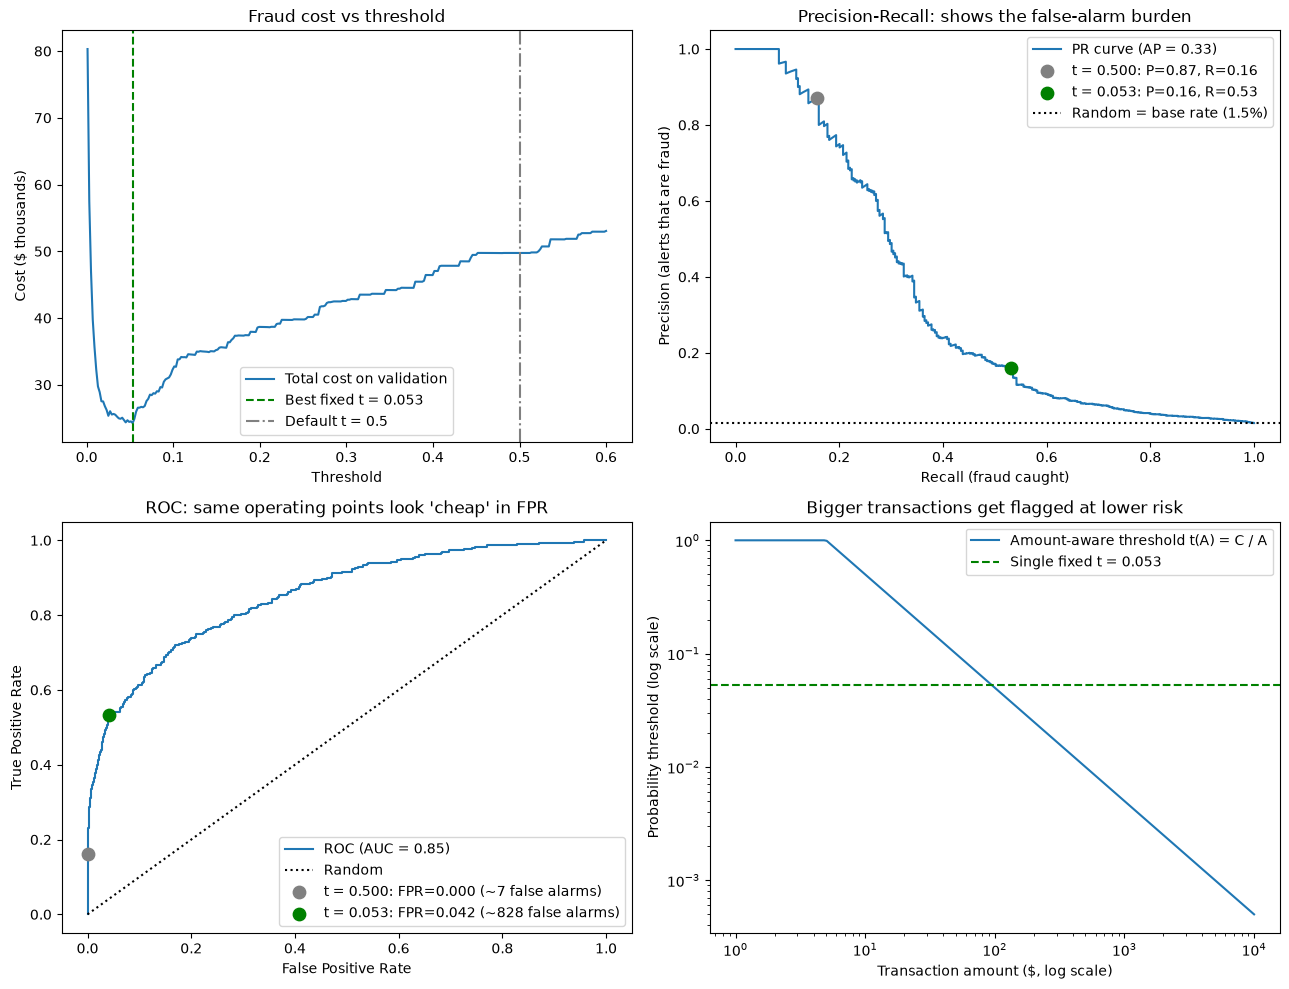

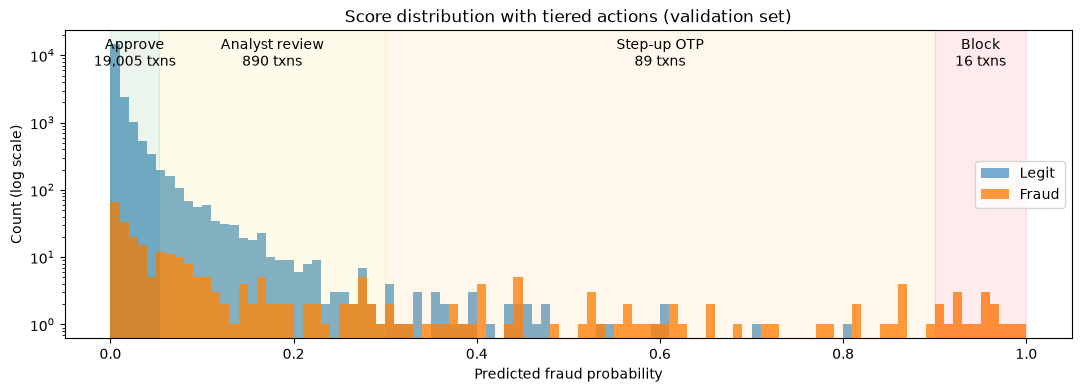

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

rng = np.random.default_rng(42)
C_REVIEW = 5  # $ cost of reviewing / challenging one flagged transaction (the FP cost)

# ~1% fraud. Fraudulent transactions tend to be larger, so amount is also a feature
X, y = make_classification(n_samples=100_000, n_features=20, n_informative=6,
                           weights=[0.99], class_sep=0.8, random_state=42)
amount = np.where(y == 1, rng.lognormal(5.0, 1.0, len(y)), rng.lognormal(3.8, 1.0, len(y)))
X = np.column_stack([X, np.log(amount)])

# Train / validation (choose threshold) / test (report) - stratified because fraud is rare
idx = np.arange(len(y))
idx_tr, idx_tmp = train_test_split(idx, test_size=0.4, stratify=y, random_state=42)
idx_val, idx_te = train_test_split(idx_tmp, test_size=0.5, stratify=y[idx_tmp], random_state=42)

# No class_weight / SMOTE, so predicted probabilities stay roughly calibrated
model = LogisticRegression(max_iter=1000).fit(X[idx_tr], y[idx_tr])
p = model.predict_proba(X)[:, 1]

def total_cost(flag, y_true, amt):
    """Missed fraud costs its full amount, every flagged transaction costs a review."""
    return amt[(y_true == 1) & ~flag].sum() + C_REVIEW * flag.sum()

# 1) Sweep a single fixed threshold on VALIDATION data
yv, pv, av = y[idx_val], p[idx_val], amount[idx_val]
thresholds = np.linspace(0.001, 0.6, 300)
costs = np.array([total_cost(pv >= t, yv, av) for t in thresholds])
t_best = thresholds[costs.argmin()]
t_star = C_REVIEW / av[yv == 1].mean()   # Bayes threshold using the average fraud amount
print(f"Validation AUC = {roc_auc_score(yv, pv):.3f} | PR-AUC = {average_precision_score(yv, pv):.3f}")
print(f"Best fixed threshold = {t_best:.3f} | formula t* = C/avg_amount = {t_star:.3f}")

# 2) Compare policies on the untouched TEST set
yt, pt, at = y[idx_te], p[idx_te], amount[idx_te]
policies = {
    "No model (approve all)":     np.zeros_like(yt, dtype=bool),
    "Default t = 0.5":            pt >= 0.5,
    f"Best fixed t = {t_best:.3f}": pt >= t_best,
    "Amount-aware: p*A > $5":     pt * at > C_REVIEW,   # threshold t(A) = C / A
}
summary = pd.DataFrame({
    name: {"alerts": f.sum(),
           "fraud caught (count)": f"{(f & (yt == 1)).sum()} / {(yt == 1).sum()}",
           "$ fraud caught": f"{at[f & (yt == 1)].sum() / at[yt == 1].sum():.1%}",
           "precision": f"{(yt[f] == 1).mean():.1%}" if f.any() else "-",
           "total cost ($)": f"{total_cost(f, yt, at):,.0f}"}
    for name, f in policies.items()}).T
print(summary.to_string())

# 3) Visualise
fpr, tpr, roc_t = roc_curve(yv, pv)
prec, rec, pr_t = precision_recall_curve(yv, pv)
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

ax = axes[0, 0]
ax.plot(thresholds, costs / 1e3, label="Total cost on validation")
ax.axvline(t_best, color="green", ls="--", label=f"Best fixed t = {t_best:.3f}")
ax.axvline(0.5, color="grey", ls="-.", label="Default t = 0.5")
ax.set(title="Fraud cost vs threshold", xlabel="Threshold", ylabel="Cost ($ thousands)")
ax.legend()

ax = axes[0, 1]
ax.plot(rec, prec, label=f"PR curve (AP = {average_precision_score(yv, pv):.2f})")
for t, c in [(0.5, "grey"), (t_best, "green")]:
    i = np.searchsorted(pr_t, t)
    ax.scatter(rec[i], prec[i], s=80, color=c, zorder=3, label=f"t = {t:.3f}: P={prec[i]:.2f}, R={rec[i]:.2f}")
ax.axhline(yv.mean(), color="black", ls=":", label=f"Random = base rate ({yv.mean():.1%})")
ax.set(title="Precision-Recall: shows the false-alarm burden", xlabel="Recall (fraud caught)",
       ylabel="Precision (alerts that are fraud)")
ax.legend()

ax = axes[1, 0]
ax.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc_score(yv, pv):.2f})")
ax.plot([0, 1], [0, 1], "k:", label="Random")
for t, c in [(0.5, "grey"), (t_best, "green")]:
    i = np.argmin(np.abs(roc_t - t))
    ax.scatter(fpr[i], tpr[i], s=80, color=c, zorder=3,
               label=f"t = {t:.3f}: FPR={fpr[i]:.3f} (~{fpr[i] * (yv == 0).sum():,.0f} false alarms)")
ax.set(title="ROC: same operating points look 'cheap' in FPR", xlabel="False Positive Rate",
       ylabel="True Positive Rate")
ax.legend(loc="lower right")

ax = axes[1, 1]
A = np.logspace(0, 4, 200)
ax.plot(A, np.minimum(C_REVIEW / A, 1), label="Amount-aware threshold t(A) = C / A")
ax.axhline(t_best, color="green", ls="--", label=f"Single fixed t = {t_best:.3f}")
ax.set(xscale="log", yscale="log", title="Bigger transactions get flagged at lower risk",
       xlabel="Transaction amount ($, log scale)", ylabel="Probability threshold (log scale)")
ax.legend()

plt.tight_layout()
plt.show()

# 4) Tiered decisions: one score, several actions
tiers = [(0.90, "Block"), (0.30, "Step-up OTP"), (t_best, "Analyst review"), (0, "Approve")]
fig, ax = plt.subplots(figsize=(13, 4))
bins = np.linspace(0, 1, 101)
ax.hist(pv[yv == 0], bins=bins, alpha=0.6, label="Legit", log=True)
ax.hist(pv[yv == 1], bins=bins, alpha=0.8, label="Fraud", log=True)
upper = 1.0
for (lo, tier), color in zip(tiers, ["red", "orange", "gold", "green"]):
    ax.axvspan(lo, upper, color=color, alpha=0.08)
    n = ((pv >= lo) & (pv < upper)).sum()
    ax.text((lo + upper) / 2, ax.get_ylim()[1] * 0.3, f"{tier}\n{n:,} txns", ha="center")
    upper = lo
ax.set(title="Score distribution with tiered actions (validation set)",
       xlabel="Predicted fraud probability", ylabel="Count (log scale)")
ax.legend(loc="center right")
plt.show()

***

## Use case 2: Customer churn prediction

**Setup.** Target = customer cancels or stops buying within the next 30/60/90 days. Features: tenure, contract type, usage trend (last 3 months vs. previous), support tickets, payment failures, discounts used, NPS. Base rate ≈ 5–20% per period. The **action** is a retention campaign (discount, call from a retention agent, free upgrade).

**What each outcome costs**

| Outcome | Business meaning | Typical cost |
|---|---|---|
| **TP** (churner contacted) | The offer saves them only with success rate $r$ | Expected gain $= r \cdot CLV - C_{offer}$ |
| **FP** (loyal customer contacted) | Offer given to someone who would have stayed anyway | $C_{offer}$ wasted (and it teaches customers to threaten to leave) |
| **FN** (churner missed) | Customer lost | CLV lost, but this is the "do nothing" baseline |

Plugging into the formula:

$$t^* = \frac{C_{offer}}{(r \cdot CLV - C_{offer}) + C_{offer}} = \frac{C_{offer}}{r \cdot CLV}$$

Example: CLV = \$600, offer = \$30, $r$ = 25%, so $t^* = 30 / 150 = 0.20$. Target customers with more than a **20%** churn probability. Note that $t^*$ depends on the **action**: a cheap email gives a very low threshold, while an expensive phone call plus a 3-month discount gives a high one.

**How it is really done in industry**

1. **Budget or capacity comes first.** Retention teams usually get a fixed budget ("call 1,000 customers this month"). So the model *ranks* customers, and the threshold is the score of the 1,000th customer. Here the evaluation metrics are **cumulative gains / lift in the top decile** and **precision@K**, not accuracy.
2. **Profit curve.** Plot expected campaign profit against the number of customers contacted, and stop where marginal profit reaches 0. This is equivalent to $t^*$, but it is much easier to explain to marketing.
3. **CLV-aware targeting.** Rank by **expected value** $p \cdot r \cdot CLV_i - C_{offer}$ instead of by $p$ alone. A high-value customer is worth a call at 10% risk, while a low-value prepaid user may only be worth an email at 50% risk.
4. **Go beyond churn probability with uplift modelling.** A high churn score does not mean the customer can be saved. Customers fall into four groups: *persuadables* (stay only if contacted, so target them), *sure things* (stay anyway, so the offer is wasted), *lost causes* (leave anyway) and *sleeping dogs* (contacting them *triggers* churn). Mature teams rank by **uplift** = $P(\text{stay} \mid \text{treated}) - P(\text{stay} \mid \text{not treated})$, estimated from an A/B test, instead of by $P(\text{churn})$.

**Pitfalls:** leakage (features like "cancellation request submitted" or "contract end date passed"), defining churn for non-contractual businesses (e.g. no purchase in 90 days), and measuring campaign success with a **control group**. Without a control group you cannot tell whether the offer saved customers or they would have stayed anyway.

### Churn: code and visualisations

The code uses a synthetic churn dataset (~15% churners) where CLV varies by customer, and evaluates four targeting policies on the test set. What to notice:

- **Profit vs threshold:** the profit peaks near the formula $t^* \approx 0.20$. The default 0.5 leaves about half the achievable profit unclaimed. The curve is flat around the optimum, so a small threshold error is cheap here, unlike in fraud.
- **Cumulative gains:** contacting the top 10% of customers by score reaches about 40% of all churners, against 10% for random targeting. That gap is the model's value.
- **Profit curve:** profit rises, peaks, then falls, because each additional contact has a lower churn probability. If the budget K is below the peak, the budget is the binding constraint and the threshold is simply the K-th score.
- **Sensitivity of t\*:** the right threshold moves a lot with offer cost and success rate. Re-derive it every time marketing changes the offer.
- **Test table:** under the same 1,000-contact budget, ranking by **expected value** (CLV-aware) earns more than ranking by churn probability, even though its precision is lower. **Precision is not profit.**

Validation AUC = 0.739
Best fixed threshold = 0.247 | formula t* = C/(r*avg CLV) = 0.201
                                   contacted precision churners reached expected profit ($)
Default t = 0.5                          369     79.4%            19.0%              33,585
Best fixed t = 0.247                    1350     55.0%            48.2%              67,858
Budget: top 1000 by P(churn)            1000     63.4%            41.1%              63,302
Budget: top 1000 by EV (CLV-aware)      1000     45.4%            29.5%              65,679
Lift in top decile = 4.11x


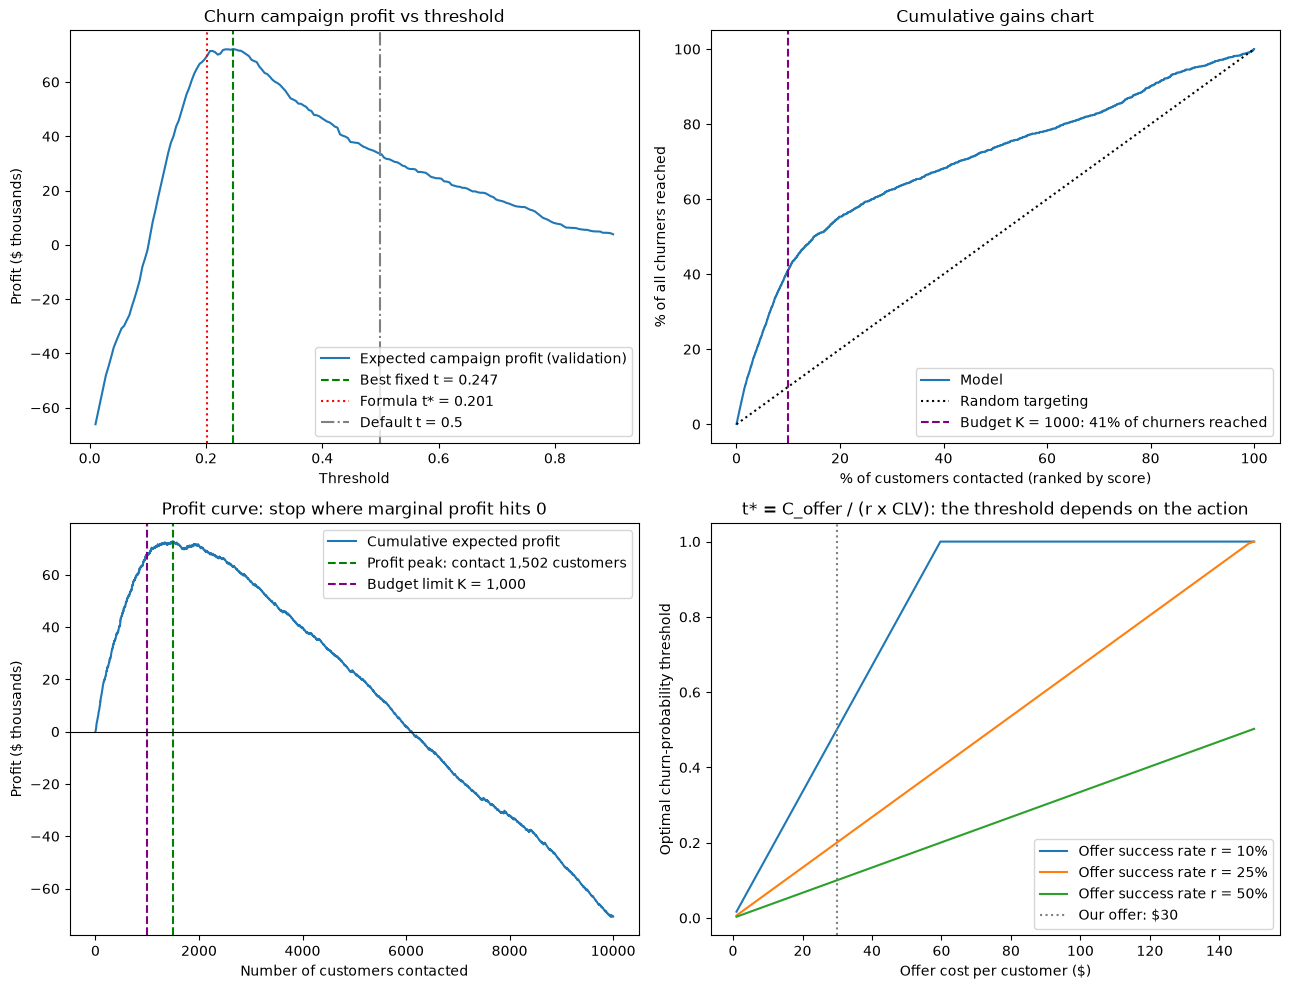

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(7)
OFFER_COST = 30     # $ per customer contacted (discount + agent time)
SUCCESS_RATE = 0.25 # share of contacted churners the offer actually retains
BUDGET_K = 1_000    # retention team can contact at most this many customers in the period

# ~15% churners; CLV varies a lot between customers (lognormal, mean ~ $600)
X, y = make_classification(n_samples=50_000, n_features=20, n_informative=6,
                           weights=[0.85], class_sep=1.2, random_state=7)
clv = rng.lognormal(np.log(600) - 0.5 * 0.6**2, 0.6, len(y))

idx = np.arange(len(y))
idx_tr, idx_tmp = train_test_split(idx, test_size=0.4, stratify=y, random_state=7)
idx_val, idx_te = train_test_split(idx_tmp, test_size=0.5, stratify=y[idx_tmp], random_state=7)
model = LogisticRegression(max_iter=1000).fit(X[idx_tr], y[idx_tr])
p = model.predict_proba(X)[:, 1]

def campaign_profit(target, y_true, clv_):
    """Expected profit vs. no campaign: a contacted churner is saved with prob SUCCESS_RATE."""
    saved_value = SUCCESS_RATE * clv_[target & (y_true == 1)].sum()
    return saved_value - OFFER_COST * target.sum()

# 1) Threshold sweep on VALIDATION
yv, pv, cv = y[idx_val], p[idx_val], clv[idx_val]
thresholds = np.linspace(0.01, 0.9, 200)
profits = np.array([campaign_profit(pv >= t, yv, cv) for t in thresholds])
t_best = thresholds[profits.argmax()]
t_star = OFFER_COST / (SUCCESS_RATE * cv.mean())  # p*r*CLV > C  ->  t* = C / (r*CLV)
print(f"Validation AUC = {roc_auc_score(yv, pv):.3f}")
print(f"Best fixed threshold = {t_best:.3f} | formula t* = C/(r*avg CLV) = {t_star:.3f}")

# 2) Compare targeting policies on TEST
yt, pt, ct = y[idx_te], p[idx_te], clv[idx_te]
ev = pt * SUCCESS_RATE * ct - OFFER_COST      # expected value of contacting each customer
top_k_by_p = np.zeros_like(yt, dtype=bool);  top_k_by_p[np.argsort(-pt)[:BUDGET_K]] = True
top_k_by_ev = np.zeros_like(yt, dtype=bool); top_k_by_ev[np.argsort(-ev)[:BUDGET_K]] = True
top_k_by_ev &= ev > 0                          # never spend on a negative-EV contact
policies = {
    "Default t = 0.5":                     pt >= 0.5,
    f"Best fixed t = {t_best:.3f}":        pt >= t_best,
    f"Budget: top {BUDGET_K} by P(churn)": top_k_by_p,
    f"Budget: top {BUDGET_K} by EV (CLV-aware)": top_k_by_ev,
}
summary = pd.DataFrame({
    name: {"contacted": f.sum(),
           "precision": f"{(yt[f] == 1).mean():.1%}",
           "churners reached": f"{(f & (yt == 1)).sum() / (yt == 1).sum():.1%}",
           "expected profit ($)": f"{campaign_profit(f, yt, ct):,.0f}"}
    for name, f in policies.items()}).T
print(summary.to_string())
top_decile = np.argsort(-pt)[:len(pt) // 10]
print(f"Lift in top decile = {yt[top_decile].mean() / yt.mean():.2f}x")

# 3) Visualise
order = np.argsort(-pv)                       # rank customers from riskiest to safest
n = np.arange(1, len(order) + 1)
captured = np.cumsum(yv[order]) / yv.sum()
cum_profit = np.cumsum(SUCCESS_RATE * cv[order] * yv[order] - OFFER_COST)
k_peak = cum_profit.argmax() + 1

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

ax = axes[0, 0]
ax.plot(thresholds, profits / 1e3, label="Expected campaign profit (validation)")
ax.axvline(t_best, color="green", ls="--", label=f"Best fixed t = {t_best:.3f}")
ax.axvline(t_star, color="red", ls=":", label=f"Formula t* = {t_star:.3f}")
ax.axvline(0.5, color="grey", ls="-.", label="Default t = 0.5")
ax.set(title="Churn campaign profit vs threshold", xlabel="Threshold", ylabel="Profit ($ thousands)")
ax.legend()

ax = axes[0, 1]
ax.plot(n / len(n) * 100, captured * 100, label="Model")
ax.plot([0, 100], [0, 100], "k:", label="Random targeting")
ax.axvline(BUDGET_K / len(n) * 100, color="purple", ls="--",
           label=f"Budget K = {BUDGET_K}: {captured[BUDGET_K - 1]:.0%} of churners reached")
ax.set(title="Cumulative gains chart", xlabel="% of customers contacted (ranked by score)",
       ylabel="% of all churners reached")
ax.legend()

ax = axes[1, 0]
ax.plot(n, cum_profit / 1e3, label="Cumulative expected profit")
ax.axvline(k_peak, color="green", ls="--", label=f"Profit peak: contact {k_peak:,} customers")
ax.axvline(BUDGET_K, color="purple", ls="--", label=f"Budget limit K = {BUDGET_K:,}")
ax.axhline(0, color="black", lw=0.8)
ax.set(title="Profit curve: stop where marginal profit hits 0", xlabel="Number of customers contacted",
       ylabel="Profit ($ thousands)")
ax.legend()

ax = axes[1, 1]
offer_costs = np.linspace(1, 150, 100)
for r in [0.10, 0.25, 0.50]:
    ax.plot(offer_costs, np.minimum(offer_costs / (r * cv.mean()), 1), label=f"Offer success rate r = {r:.0%}")
ax.axvline(OFFER_COST, color="grey", ls=":", label=f"Our offer: ${OFFER_COST}")
ax.set(title="t* = C_offer / (r x CLV): the threshold depends on the action",
       xlabel="Offer cost per customer ($)", ylabel="Optimal churn-probability threshold")
ax.legend()

plt.tight_layout()
plt.show()

***

## Fraud vs churn: side by side

| | Credit card fraud | Churn prediction |
|---|---|---|
| Base rate | 0.1–1% | 5–20% |
| Optimal threshold | $t^* = C_{review} / A$ | $t^* = C_{offer} / (r \cdot CLV)$ |
| Cost asymmetry | $C_{FN} \gg C_{FP}$ (loss of amount vs. review) | Moderate (saved CLV × success rate vs. offer cost) |
| Typical threshold | Very low (≈ 0.01–0.1), varies with amount | Low to moderate (≈ 0.2–0.4), varies with offer and CLV |
| Main constraint | Analyst capacity, false-decline rate, latency | Campaign budget |
| Decision style | Tiered: block / OTP / review / approve | Top-K ranking, segment-specific offers |
| Curve to show the business | Precision–recall, cost vs threshold | Cumulative gains / lift, profit curve |
| Metric the business watches | Recall at fixed FPR, \$ fraud caught, alert precision | Lift@top decile, precision@K, campaign ROI vs. control |
| Next level | Amount-aware cost-sensitive learning | Uplift modelling |

## Interview questions

1. Your fraud model has AUC = 0.97. The business says it generates too many alerts. What do you change: the model or the threshold? Which curve do you show them?
2. A false negative costs \$400 and a false positive costs \$10. What is the optimal threshold, and what assumption does it rely on?
3. Why might targeting the customers with the highest churn probability lose money for a retention campaign?

<details>
<summary>Answers</summary>

1. Start with the threshold (and possibly tiered actions). AUC measures ranking quality, and the alert volume is set by the threshold. Show the **precision–recall curve** or alerts-per-day vs. recall, because with extreme imbalance ROC hides how many false positives you get. If no threshold meets the capacity and recall targets together, then improve the model (features, data).
2. $t^* = \dfrac{10}{10 + 400} \approx 0.024$. It assumes **calibrated probabilities** and constant costs per case. If the model was trained with resampling or class weights, calibrate first or tune the threshold empirically on validation data.
3. High churn probability ≠ responsive to the offer. Many top-scored customers are *lost causes* (leave anyway), and some are *sleeping dogs* whom contact pushes to leave. Meanwhile, offers given to *sure things* are wasted, and low-CLV customers may not be worth the offer cost at all. Rank by expected value or uplift, and validate with a control group.

</details>

**References:** Provost & Fawcett, *Data Science for Business* (expected value framework, profit curves); Elkan (2001), *The Foundations of Cost-Sensitive Learning*; scikit-learn docs on `TunedThresholdClassifierCV` and probability calibration.